In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import plotly.express as px
import plotly.graph_objects as go

plt.style.use("ggplot")

print("Libraries Loaded Successfully")

Libraries Loaded Successfully


# 1. NAV Trend Analysis

In [2]:
import pandas as pd

nav = pd.read_csv("../data/processed/02_nav_history_clean.csv")

print(nav.shape)

nav.head()

(46000, 3)


,amfi_code,date,nav
0,100016,2022-01-03,520.4608
1,100016,2022-01-04,515.0971
2,100016,2022-01-05,521.7239
3,100016,2022-01-06,515.7880
4,100016,2022-01-07,515.1639


In [3]:
print(nav.columns.tolist())

['amfi_code', 'date', 'nav']


In [4]:
nav["date"] = pd.to_datetime(nav["date"])

nav.info()

<class 'pandas.DataFrame'>
RangeIndex: 46000 entries, 0 to 45999
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   amfi_code  46000 non-null  int64         
 1   date       46000 non-null  datetime64[us]
 2   nav        46000 non-null  float64       
dtypes: datetime64[us](1), float64(1), int64(1)
memory usage: 1.1 MB


In [5]:
print("Total Schemes =", nav["amfi_code"].nunique())


Total Schemes = 40


In [6]:
import plotly.express as px

fig = px.line(
    nav,
    x="date",
    y="nav",
    color="amfi_code",
    title="NAV Trend Analysis (2022-2026)"
)

fig.show()

In [7]:
fig.write_image(
    "../reports/charts/nav_trend_analysis.png"
)

# 2. AUM Growth Analysis

In [8]:
aum = pd.read_csv("../data/processed/03_aum_by_fund_house_clean.csv")

print(aum.shape)

aum.head()

(90, 5)


,date,fund_house,aum_lakh_crore,aum_crore,num_schemes
0,2022-03-31,SBI Mutual Fund,6.05,605000,186
1,2022-03-31,ICICI Prudential MF,4.65,465000,216
2,2022-03-31,HDFC Mutual Fund,4.35,435000,195
3,2022-03-31,Nippon India MF,2.70,270000,177
4,2022-03-31,Kotak Mahindra MF,2.70,270000,168


In [9]:
print(aum.columns.tolist())

['date', 'fund_house', 'aum_lakh_crore', 'aum_crore', 'num_schemes']


In [10]:
aum["date"] = pd.to_datetime(aum["date"])

aum.info()

<class 'pandas.DataFrame'>
RangeIndex: 90 entries, 0 to 89
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   date            90 non-null     datetime64[us]
 1   fund_house      90 non-null     str           
 2   aum_lakh_crore  90 non-null     float64       
 3   aum_crore       90 non-null     int64         
 4   num_schemes     90 non-null     int64         
dtypes: datetime64[us](1), float64(1), int64(2), str(1)
memory usage: 3.6 KB


In [11]:
aum["year"] = aum["date"].dt.year

aum[["date","year"]].head()

,date,year
0,2022-03-31,2022
1,2022-03-31,2022
2,2022-03-31,2022
3,2022-03-31,2022
4,2022-03-31,2022


In [12]:
yearly_aum = (
    aum.groupby(
        ["year","fund_house"]
    )["aum_lakh_crore"]
    .mean()
    .reset_index()
)

yearly_aum.head()

,year,fund_house,aum_lakh_crore
0,2022,Aditya Birla Sun Life MF,2.815
1,2022,Axis Mutual Fund,2.450
2,2022,DSP Mutual Fund,1.110
3,2022,HDFC Mutual Fund,4.400
4,2022,ICICI Prudential MF,4.765


In [13]:
yearly_aum.sort_values(
    "aum_lakh_crore",
    ascending=False
).head(10)

,year,fund_house,aum_lakh_crore
38,2025,SBI Mutual Fund,12.500000
28,2024,SBI Mutual Fund,10.646667
34,2025,ICICI Prudential MF,9.770000
33,2025,HDFC Mutual Fund,8.625000
18,2023,SBI Mutual Fund,7.810000
24,2024,ICICI Prudential MF,7.653333
23,2024,HDFC Mutual Fund,7.140000
37,2025,Nippon India MF,6.300000
8,2022,SBI Mutual Fund,6.175000
14,2023,ICICI Prudential MF,5.450000


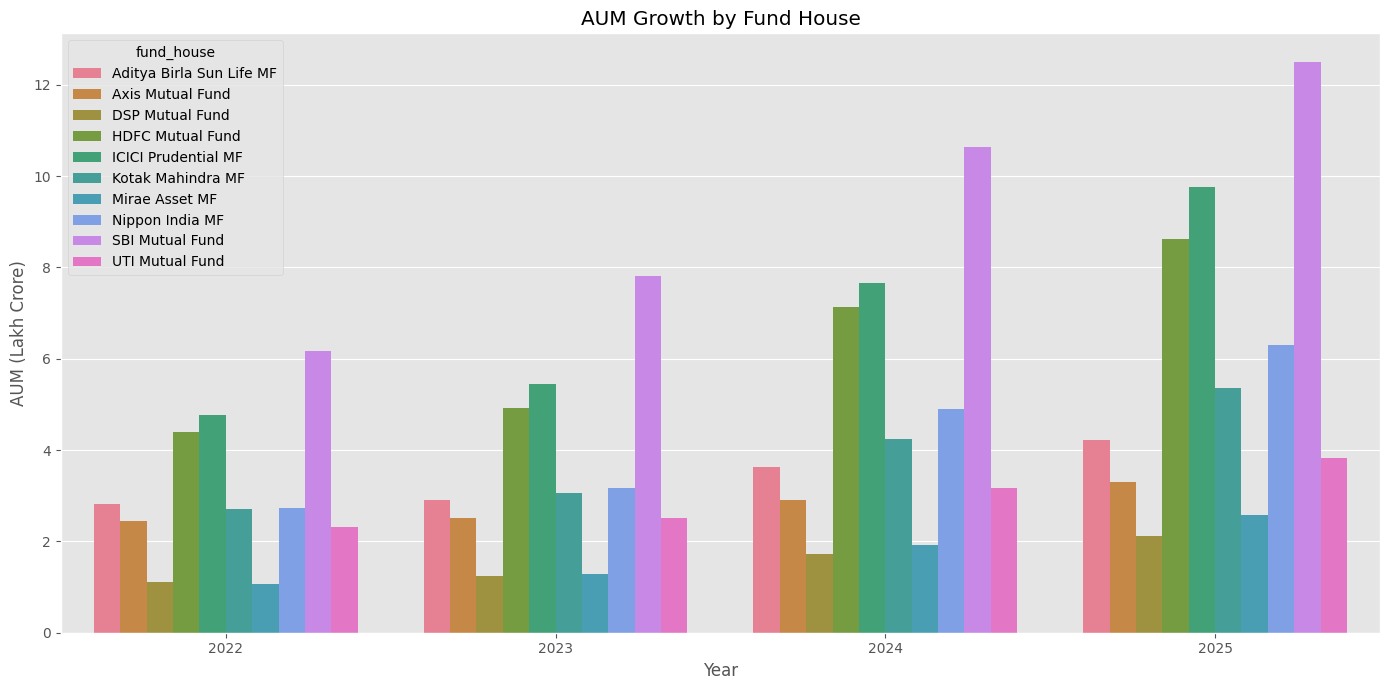

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(14,7))

sns.barplot(
    data=yearly_aum,
    x="year",
    y="aum_lakh_crore",
    hue="fund_house"
)

plt.title("AUM Growth by Fund House")
plt.xlabel("Year")
plt.ylabel("AUM (Lakh Crore)")
plt.xticks(rotation=0)

plt.tight_layout()

plt.show()

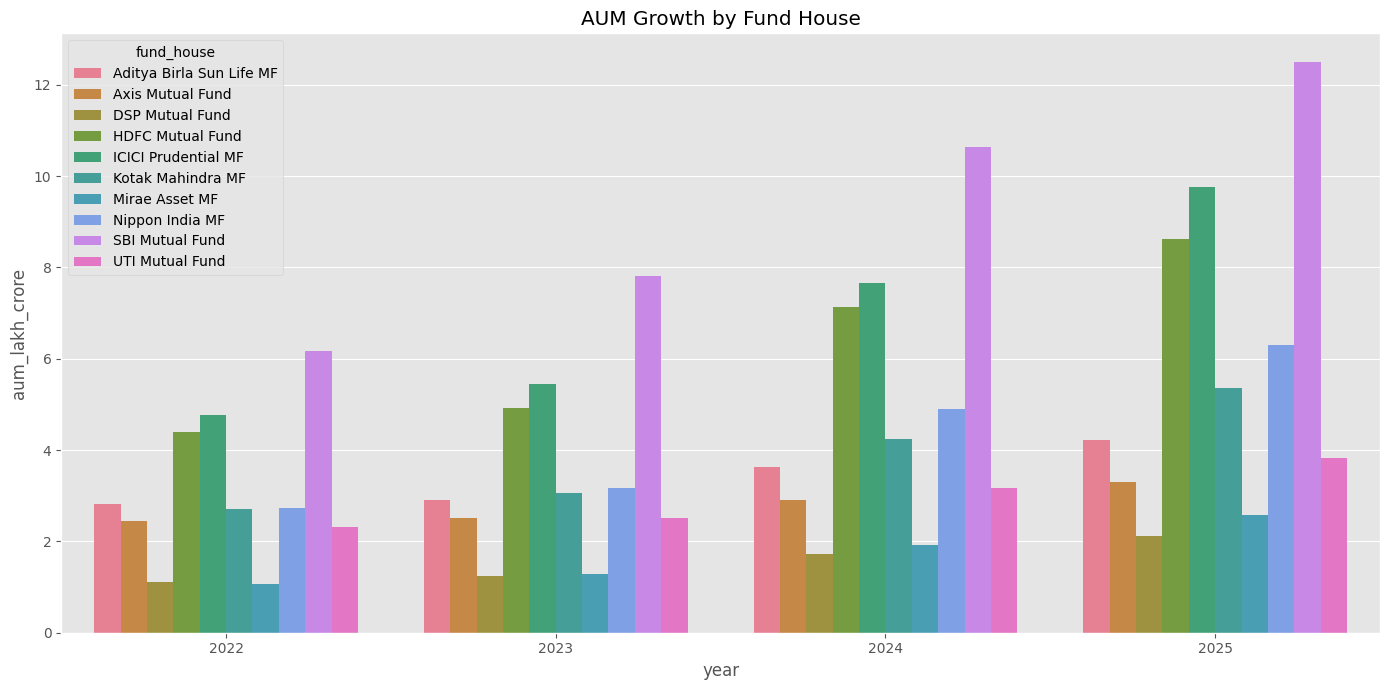

In [15]:
plt.figure(figsize=(14,7))

sns.barplot(
    data=yearly_aum,
    x="year",
    y="aum_lakh_crore",
    hue="fund_house"
)

plt.title("AUM Growth by Fund House")

plt.tight_layout()

plt.savefig(
    "../reports/charts/aum_growth_analysis.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Insight

SBI Mutual Fund consistently maintained the highest Assets Under Management (AUM) among all fund houses during the analysis period. The overall mutual fund industry showed steady growth in AUM between 2022 and 2025, indicating increasing investor participation and market expansion.

# 3. SIP Inflow Trend Analysis

In [16]:
sip = pd.read_csv(
    "../data/processed/04_monthly_sip_inflows_clean.csv"
)

print(sip.shape)

sip.head()

(48, 6)


,month,sip_inflow_crore,active_sip_accounts_crore,new_sip_accounts_lakh,sip_aum_lakh_crore,yoy_growth_pct
0,2022-01,11517,4.91,9.10,4.80,NaN
1,2022-02,11438,4.93,8.20,4.85,NaN
2,2022-03,12328,5.09,10.50,5.01,NaN
3,2022-04,11863,5.48,9.52,5.12,NaN
4,2022-05,12286,5.55,8.10,5.15,NaN


In [17]:
print(sip.columns.tolist())

['month', 'sip_inflow_crore', 'active_sip_accounts_crore', 'new_sip_accounts_lakh', 'sip_aum_lakh_crore', 'yoy_growth_pct']


In [18]:
sip.info()

<class 'pandas.DataFrame'>
RangeIndex: 48 entries, 0 to 47
Data columns (total 6 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   month                      48 non-null     str    
 1   sip_inflow_crore           48 non-null     int64  
 2   active_sip_accounts_crore  48 non-null     float64
 3   new_sip_accounts_lakh      48 non-null     float64
 4   sip_aum_lakh_crore         48 non-null     float64
 5   yoy_growth_pct             36 non-null     float64
dtypes: float64(4), int64(1), str(1)
memory usage: 2.4 KB


In [19]:
sip["month"] = pd.to_datetime(sip["month"])

sip.info()

<class 'pandas.DataFrame'>
RangeIndex: 48 entries, 0 to 47
Data columns (total 6 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   month                      48 non-null     datetime64[us]
 1   sip_inflow_crore           48 non-null     int64         
 2   active_sip_accounts_crore  48 non-null     float64       
 3   new_sip_accounts_lakh      48 non-null     float64       
 4   sip_aum_lakh_crore         48 non-null     float64       
 5   yoy_growth_pct             36 non-null     float64       
dtypes: datetime64[us](1), float64(4), int64(1)
memory usage: 2.4 KB


In [23]:
peak = sip.loc[
    sip["sip_inflow_crore"].idxmax()
]

peak

month                        2025-12-01 00:00:00
sip_inflow_crore                           31002
active_sip_accounts_crore                   9.35
new_sip_accounts_lakh                        9.8
sip_aum_lakh_crore                          15.9
yoy_growth_pct                             17.17
Name: 47, dtype: object

In [ ]:
fig = px.line(
    sip,
    x="month",
    y="sip_inflow_crore",
    title="Monthly SIP Inflow Trend (2022-2025)",
    markers=True
)

fig.add_annotation(
    x=str(peak["month"].date()),
    y=peak["sip_inflow_crore"],
    text=f"Peak SIP = ₹{peak['sip_inflow_crore']:,} Cr",
    showarrow=True
)

fig.update_layout(
    xaxis_title="Month",
    yaxis_title="SIP Inflow (Crore ₹)",
    template="plotly_white"
)

fig.show()

## Insight

Most mutual fund investors belong to middle-income segments. Participation gradually decreases in higher income brackets, indicating strong retail penetration among salaried and emerging affluent investors.

# 4. Category Inflow Heatmap

In [26]:
category = pd.read_csv(
    "../data/processed/05_category_inflows_clean.csv"
)

print(category.shape)

category.head()

(144, 3)


,month,category,net_inflow_crore
0,2024-04,Large Cap,2413.0
1,2024-04,Mid Cap,3897.0
2,2024-04,Small Cap,3533.0
3,2024-04,Flexi Cap,4947.0
4,2024-04,Large & Mid Cap,4214.0


In [27]:
print(category.columns.tolist())

['month', 'category', 'net_inflow_crore']


In [28]:
category["month"] = pd.to_datetime(
    category["month"]
)

category.head()

,month,category,net_inflow_crore
0,2024-04-01,Large Cap,2413.0
1,2024-04-01,Mid Cap,3897.0
2,2024-04-01,Small Cap,3533.0
3,2024-04-01,Flexi Cap,4947.0
4,2024-04-01,Large & Mid Cap,4214.0


In [29]:
heatmap_data = category.pivot_table(
    index="category",
    columns="month",
    values="net_inflow_crore",
    aggfunc="sum"
)

heatmap_data.head()

month,2024-04-01,2024-05-01,2024-06-01,2024-07-01,2024-08-01,2024-09-01,2024-10-01,2024-11-01,2024-12-01,2025-01-01,2025-02-01,2025-03-01
category,,,,,,,,,,,,
ELSS,466.0,553.0,472.0,471.0,499.0,537.0,537.0,571.0,521.0,516.0,437.0,500.0
Flexi Cap,4947.0,5529.0,4478.0,4869.0,5562.0,5397.0,6004.0,6111.0,4654.0,5603.0,6068.0,4767.0
Gilt,784.0,836.0,864.0,959.0,952.0,925.0,898.0,704.0,831.0,744.0,942.0,956.0
Hybrid,2955.0,3487.0,3163.0,3291.0,3684.0,3015.0,3314.0,3264.0,3538.0,2967.0,3360.0,2830.0
Large & Mid Cap,4214.0,4368.0,4610.0,5023.0,5411.0,4528.0,4581.0,5556.0,4878.0,4816.0,5524.0,4243.0


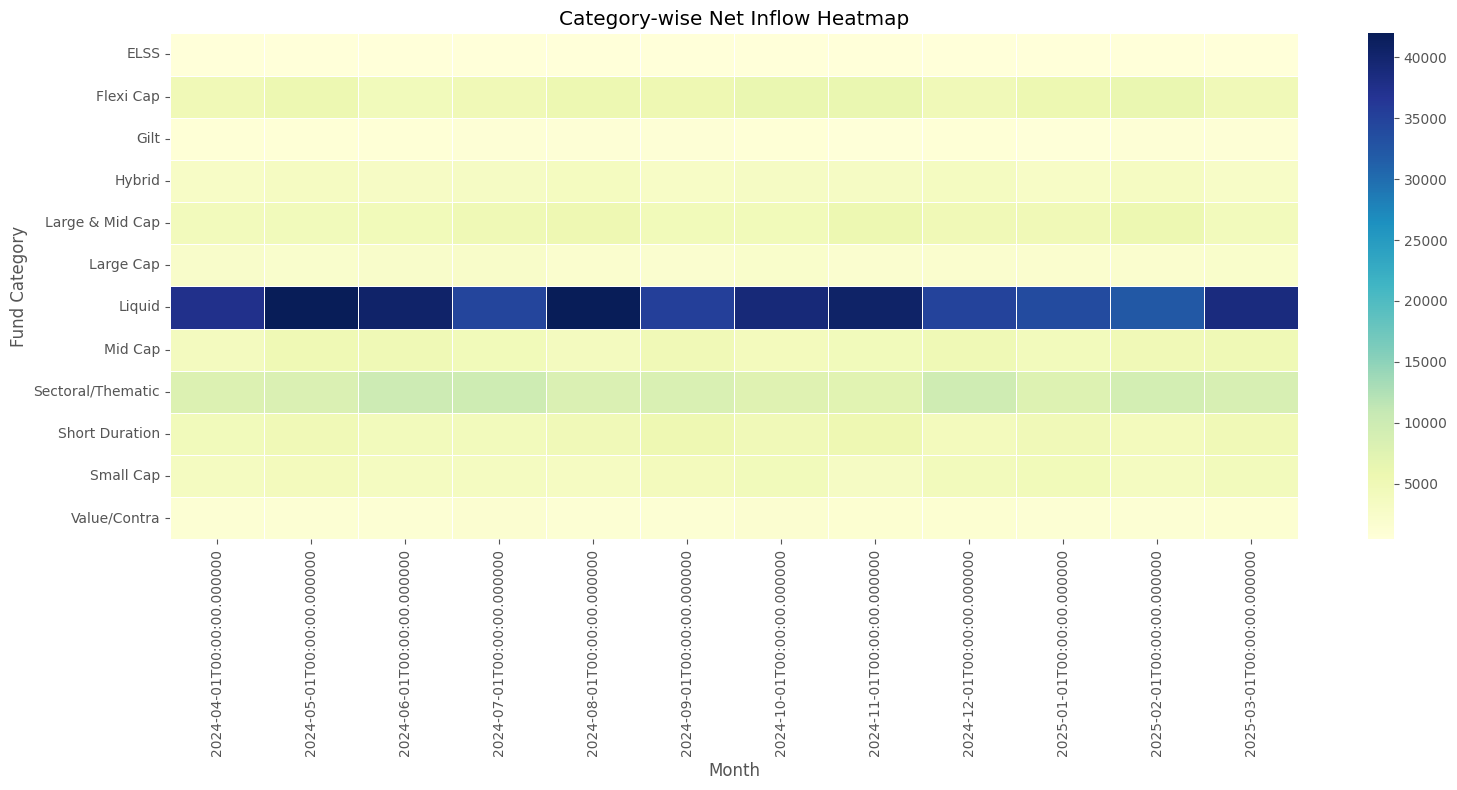

In [30]:
plt.figure(figsize=(16,8))

sns.heatmap(
    heatmap_data,
    cmap="YlGnBu",
    linewidths=0.5
)

plt.title(
    "Category-wise Net Inflow Heatmap"
)

plt.xlabel("Month")
plt.ylabel("Fund Category")

plt.tight_layout()

plt.show()

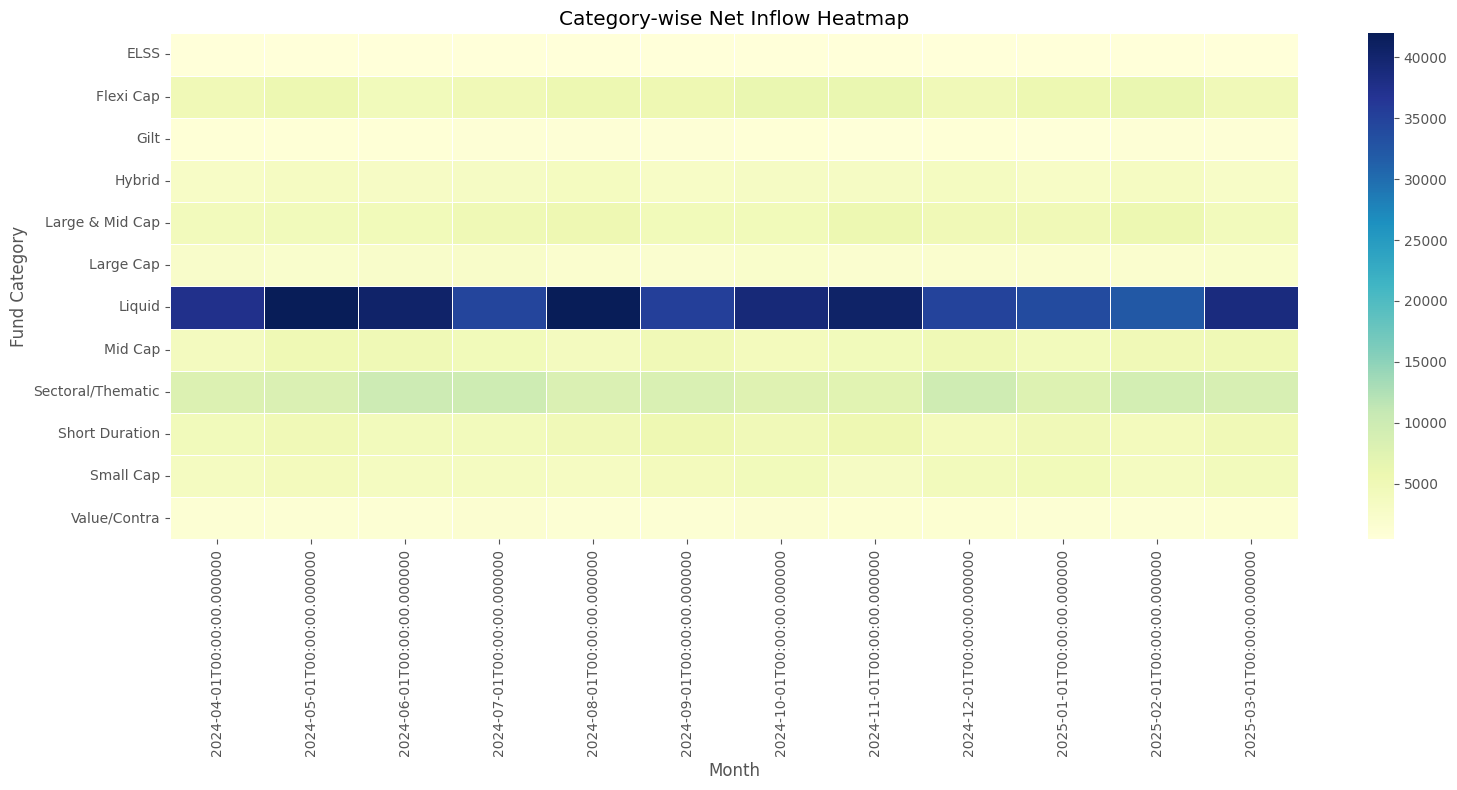

In [31]:
plt.figure(figsize=(16,8))

sns.heatmap(
    heatmap_data,
    cmap="YlGnBu",
    linewidths=0.5
)

plt.title(
    "Category-wise Net Inflow Heatmap"
)

plt.xlabel("Month")
plt.ylabel("Fund Category")

plt.tight_layout()

plt.savefig(
    "../reports/charts/category_inflow_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Insight

Fund inflows varied significantly across categories during the analysis period. Flexi Cap, Mid Cap, Small Cap, and Large & Mid Cap categories consistently attracted higher investor inflows compared to other categories. The heatmap highlights periods of strong investor preference toward equity-oriented schemes, indicating increased risk appetite and confidence in market growth.

# 5. Investor Demographics Analysis

In [32]:
txn = pd.read_csv(
    "../data/processed/08_investor_transactions_clean.csv"
)

print(txn.shape)

txn.head()

(32778, 13)


,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status
0,INV003054,2024-01-01,119092,Sip,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified
1,INV002952,2024-01-01,148567,Redemption,392882,Punjab,Amritsar,B30,18-25,Male,7.1,Cheque,Verified
2,INV003420,2024-01-01,118636,Sip,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified
3,INV003436,2024-01-01,118634,Sip,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending
4,INV004691,2024-01-01,119094,Lumpsum,8682,Delhi,Noida,T30,26-35,Male,14.5,Net Banking,Pending


In [33]:
print(txn.columns.tolist())

['investor_id', 'transaction_date', 'amfi_code', 'transaction_type', 'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender', 'annual_income_lakh', 'payment_mode', 'kyc_status']


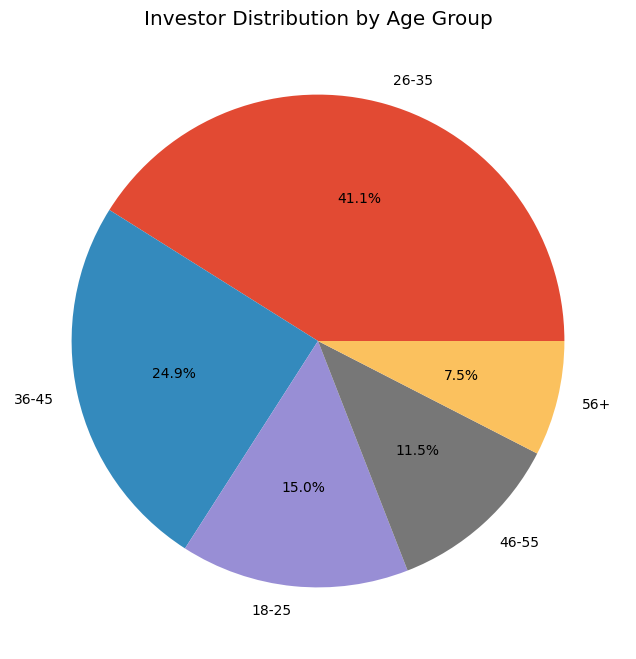

In [34]:
age_counts = txn["age_group"].value_counts()

plt.figure(figsize=(8,8))

plt.pie(
    age_counts,
    labels=age_counts.index,
    autopct="%1.1f%%"
)

plt.title("Investor Distribution by Age Group")

plt.savefig(
    "../reports/charts/age_group_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Insight

The majority of investors belong to the 26–35 and 36–45 age groups, indicating strong participation from working professionals. Younger investors are increasingly adopting mutual funds as a long-term wealth creation tool, while senior investors contribute a comparatively smaller share.

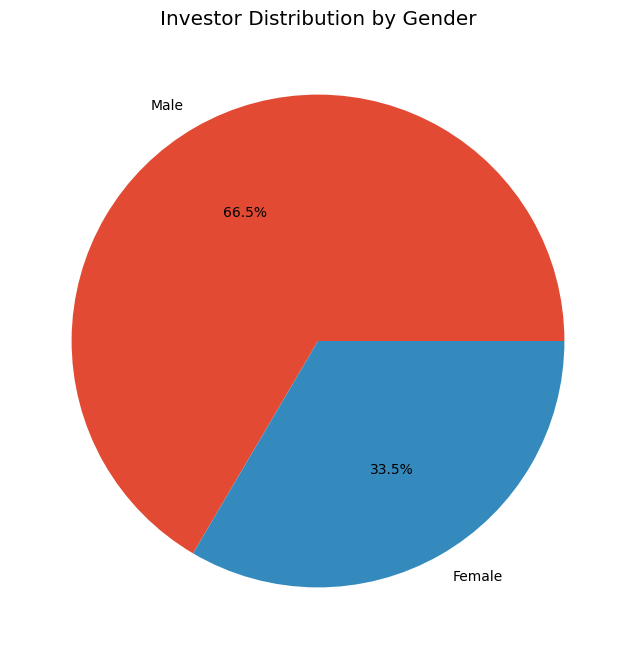

In [35]:
gender_counts = txn["gender"].value_counts()

plt.figure(figsize=(8,8))

plt.pie(
    gender_counts,
    labels=gender_counts.index,
    autopct="%1.1f%%"
)

plt.title("Investor Distribution by Gender")

plt.savefig(
    "../reports/charts/gender_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Insight

Male investors constitute the majority of mutual fund participants, while female participation continues to grow steadily. The distribution indicates increasing awareness and adoption of investment products across different demographic segments.

In [36]:
sip_txn = txn[
    txn["transaction_type"] == "Sip"
]

sip_txn.shape

(19716, 13)

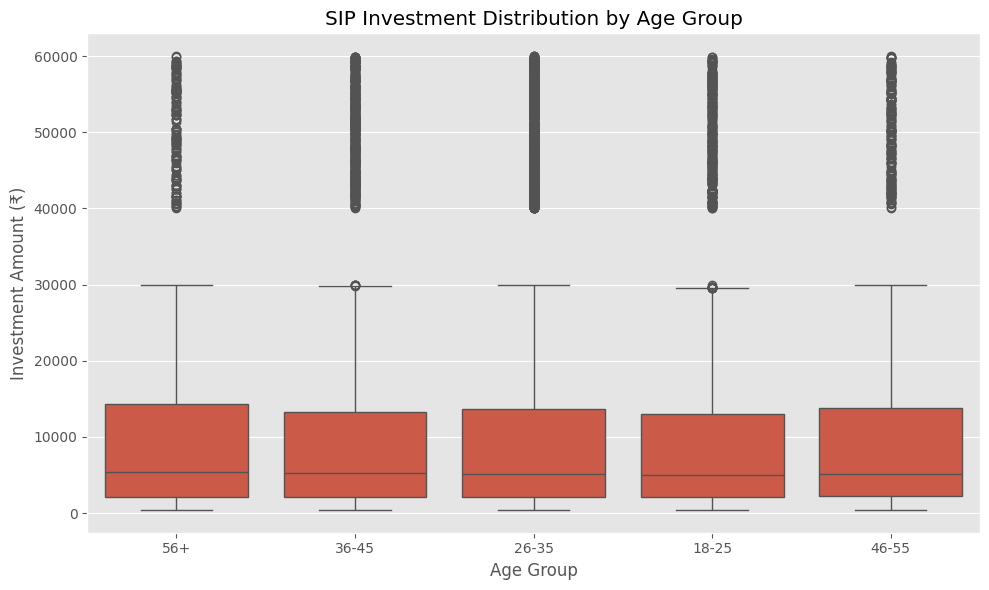

In [37]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=sip_txn,
    x="age_group",
    y="amount_inr"
)

plt.title(
    "SIP Investment Distribution by Age Group"
)

plt.xlabel("Age Group")
plt.ylabel("Investment Amount (₹)")

plt.tight_layout()

plt.savefig(
    "../reports/charts/sip_boxplot_age_group.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Insight

Middle-aged investors generally contribute larger SIP amounts compared to younger investors. The boxplot reveals significant variability in investment behavior, with several high-value outliers indicating the presence of affluent investors across age groups.

# 6. Geographic Distribution Analysis

In [38]:
state_sip = (
    txn.groupby("state")["amount_inr"]
    .sum()
    .sort_values(ascending=False)
    .head(15)
)

state_sip

state
Punjab            315780459
Tamil Nadu        315177237
Madhya Pradesh    308312493
Rajasthan         298645822
Gujarat           298358940
West Bengal       297182514
Telangana         290219284
Delhi             289633404
Uttar Pradesh     285368873
Haryana           279634354
Karnataka         273753570
Maharashtra       269513480
Name: amount_inr, dtype: int64

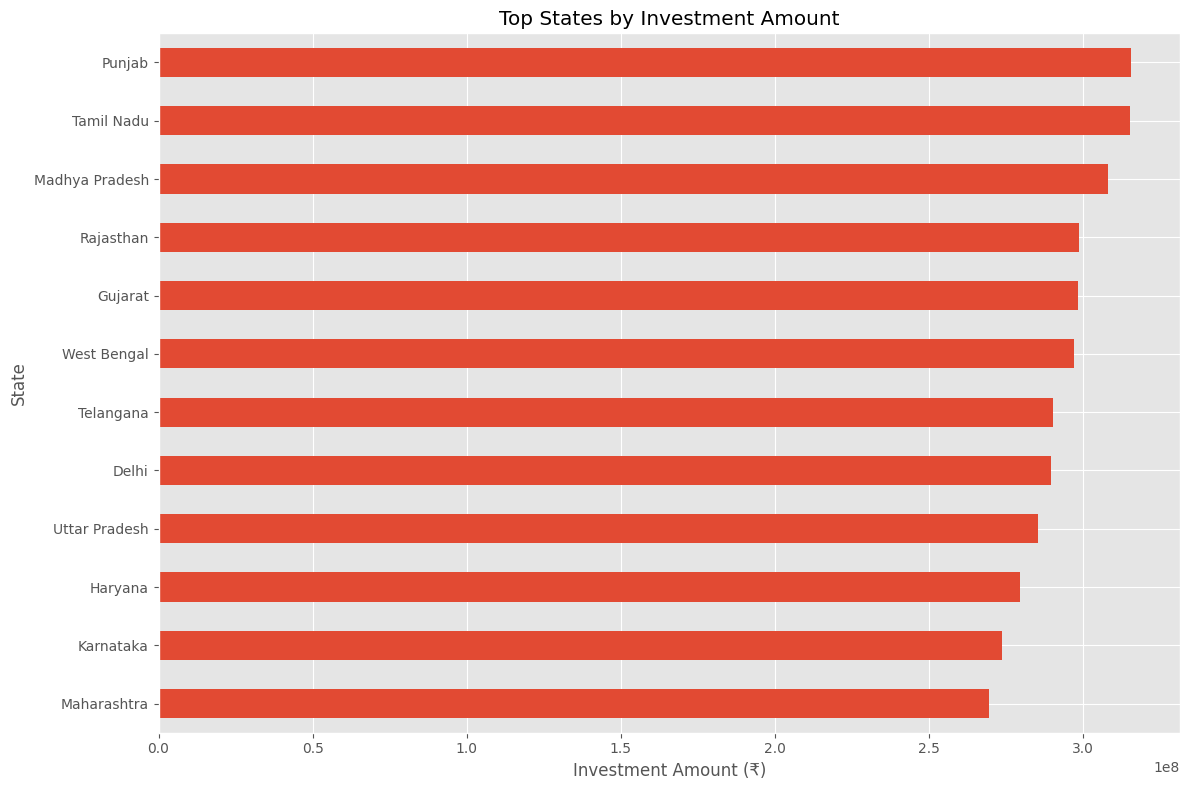

In [39]:
plt.figure(figsize=(12,8))

state_sip.sort_values().plot(
    kind="barh"
)

plt.title(
    "Top States by Investment Amount"
)

plt.xlabel("Investment Amount (₹)")
plt.ylabel("State")

plt.tight_layout()

plt.savefig(
    "../reports/charts/state_investment_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Insight

Major metropolitan states such as Maharashtra, Karnataka, Delhi, Tamil Nadu, and Telangana contribute the highest investment volumes. This reflects greater financial awareness, higher disposable income, and stronger penetration of mutual fund products in urban markets.

In [40]:
print(
    txn["city_tier"].value_counts()
)

city_tier
T30    21719
B30    11059
Name: count, dtype: int64


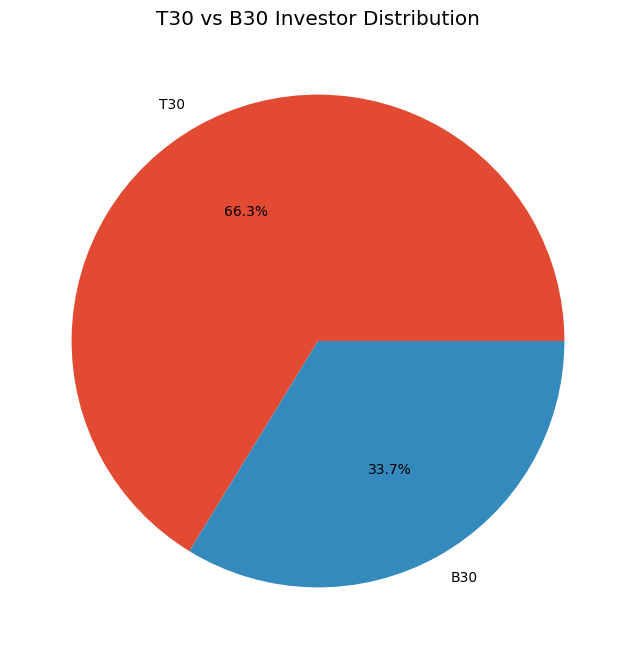

In [41]:
tier_counts = txn["city_tier"].value_counts()

plt.figure(figsize=(8,8))

plt.pie(
    tier_counts,
    labels=tier_counts.index,
    autopct="%1.1f%%"
)

plt.title(
    "T30 vs B30 Investor Distribution"
)

plt.savefig(
    "../reports/charts/t30_b30_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Insight

T30 cities continue to dominate mutual fund participation due to stronger financial infrastructure and investor awareness. However, B30 cities represent a growing opportunity for asset management companies, indicating increasing market penetration beyond metropolitan regions.

# 7. Folio Count Growth Analysis

In [42]:
folios = pd.read_csv(
    "../data/processed/06_industry_folio_count_clean.csv"
)

print(folios.shape)

folios.head()

(21, 6)


,month,total_folios_crore,equity_folios_crore,debt_folios_crore,hybrid_folios_crore,others_folios_crore
0,2022-01,13.26,9.28,1.86,0.80,1.33
1,2022-04,13.91,9.74,1.95,0.83,1.39
2,2022-07,13.85,9.69,1.94,0.83,1.38
3,2022-10,14.12,9.88,1.98,0.85,1.41
4,2023-01,14.81,10.37,2.07,0.89,1.48


In [43]:
print(
    folios.columns.tolist()
)

['month', 'total_folios_crore', 'equity_folios_crore', 'debt_folios_crore', 'hybrid_folios_crore', 'others_folios_crore']


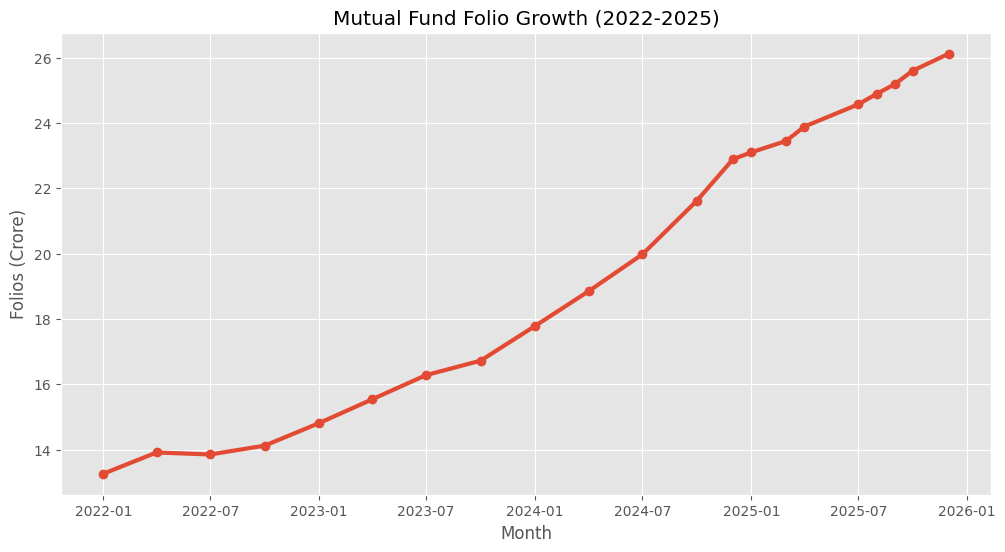

In [44]:
folios["month"] = pd.to_datetime(
    folios["month"]
)

plt.figure(figsize=(12,6))

plt.plot(
    folios["month"],
    folios["total_folios_crore"],
    marker="o",
    linewidth=3
)

plt.title(
    "Mutual Fund Folio Growth (2022-2025)"
)

plt.xlabel("Month")
plt.ylabel("Folios (Crore)")

plt.grid(True)

plt.savefig(
    "../reports/charts/folio_growth_trend.png",
    bbox_inches="tight"
)

plt.show()

## Insight

Total mutual fund folios increased steadily throughout the analysis period, indicating continuous expansion of the investor base. The rise in folio count reflects growing awareness of mutual fund investing, improved digital accessibility, and increased participation from retail investors.

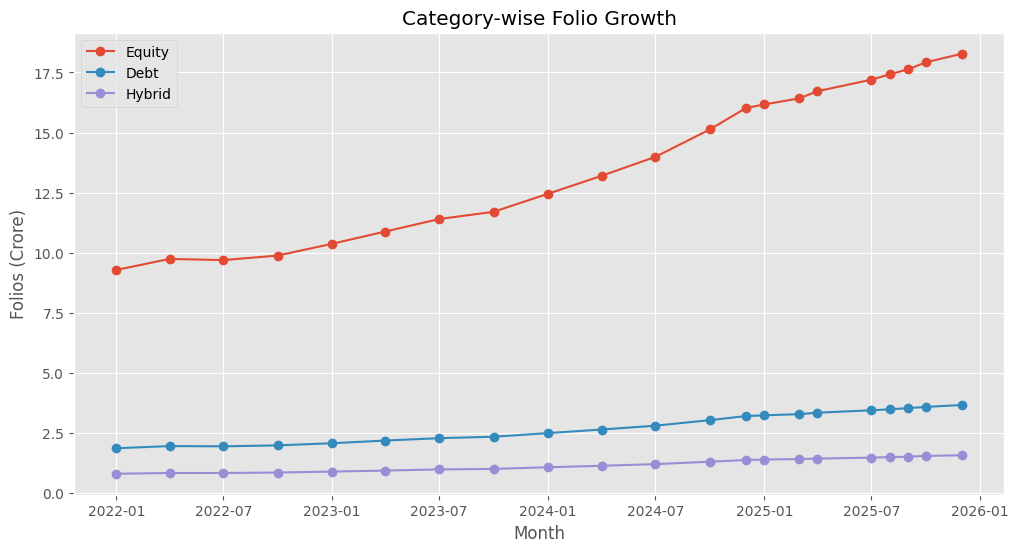

In [45]:
plt.figure(figsize=(12,6))

plt.plot(
    folios["month"],
    folios["equity_folios_crore"],
    marker="o",
    label="Equity"
)

plt.plot(
    folios["month"],
    folios["debt_folios_crore"],
    marker="o",
    label="Debt"
)

plt.plot(
    folios["month"],
    folios["hybrid_folios_crore"],
    marker="o",
    label="Hybrid"
)

plt.title(
    "Category-wise Folio Growth"
)

plt.xlabel("Month")
plt.ylabel("Folios (Crore)")

plt.legend()

plt.grid(True)

plt.savefig(
    "../reports/charts/category_folio_growth.png",
    bbox_inches="tight"
)

plt.show()

## Insight

Equity folios dominate the mutual fund industry and exhibited the strongest growth throughout the analysis period. Debt and hybrid folios grew at a comparatively slower pace, reflecting stronger investor preference for equity-oriented investment products during a rising market environment.

# 8. NAV Return Correlation Matrix

In [46]:
nav = pd.read_csv(
    "../data/processed/02_nav_history_clean.csv"
)

nav["date"] = pd.to_datetime(
    nav["date"]
)

nav.head()

,amfi_code,date,nav
0,100016,2022-01-03,520.4608
1,100016,2022-01-04,515.0971
2,100016,2022-01-05,521.7239
3,100016,2022-01-06,515.7880
4,100016,2022-01-07,515.1639


In [47]:
selected_funds = (
    nav["amfi_code"]
    .unique()[:10]
)

selected_funds

array([100016, 100025, 100033, 101206, 101207, 101208, 102885, 102886,
       102887, 118632])

In [48]:
nav_10 = nav[
    nav["amfi_code"].isin(selected_funds)
]

print(nav_10.shape)

nav_10.head()

(11500, 3)


,amfi_code,date,nav
0,100016,2022-01-03,520.4608
1,100016,2022-01-04,515.0971
2,100016,2022-01-05,521.7239
3,100016,2022-01-06,515.7880
4,100016,2022-01-07,515.1639


In [53]:
nav_pivot = nav_10.pivot(
    index="date",
    columns="amfi_code",
    values="nav"
)

nav_pivot.head()

amfi_code,100016,100025,100033,101206,101207,101208,102885,102886,102887,118632
date,,,,,,,,,,
2022-01-03,520.4608,26.3169,107.3758,305.0996,38.5736,310.7415,89.8728,119.2905,191.0721,42.8339
2022-01-04,515.0971,26.2234,105.9447,305.4514,38.1545,310.6977,90.8724,120.6402,189.0737,42.8033
2022-01-05,521.7239,26.2221,105.4800,306.6324,38.1775,310.8165,90.1565,121.4580,188.0701,43.0564
2022-01-06,515.7880,26.1728,104.9350,305.9800,37.0665,310.7719,91.5338,125.2386,190.4545,43.2088
2022-01-07,515.1639,26.2261,104.3318,304.0480,37.9845,310.8388,90.6762,124.1321,187.3124,42.9585


In [54]:
returns = nav_pivot.pct_change()

returns.head()

amfi_code,100016,100025,100033,101206,101207,101208,102885,102886,102887,118632
date,,,,,,,,,,
2022-01-03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2022-01-04,-0.010306,-0.003553,-0.013328,0.001153,-0.010865,-0.000141,0.011122,0.011314,-0.010459,-0.000714
2022-01-05,0.012865,-0.000050,-0.004386,0.003866,0.000603,0.000382,-0.007878,0.006779,-0.005308,0.005913
2022-01-06,-0.011377,-0.001880,-0.005167,-0.002128,-0.029101,-0.000143,0.015277,0.031127,0.012678,0.003540
2022-01-07,-0.001210,0.002036,-0.005748,-0.006314,0.024766,0.000215,-0.009369,-0.008835,-0.016498,-0.005793


In [55]:
corr_matrix = returns.corr()

corr_matrix

amfi_code,100016,100025,100033,101206,101207,101208,102885,102886,102887,118632
amfi_code,,,,,,,,,,
100016,1.000000,0.045567,-0.000006,0.027747,0.016053,-0.033773,-0.093533,-0.005867,-0.023316,-0.026781
100025,0.045567,1.000000,0.002150,0.023769,-0.006710,0.018455,-0.001038,0.013754,-0.005648,-0.014166
100033,-0.000006,0.002150,1.000000,-0.018079,0.000351,0.007864,-0.034228,-0.018166,-0.036647,-0.013318
101206,0.027747,0.023769,-0.018079,1.000000,0.010202,-0.027230,0.001570,0.007229,-0.006490,-0.005432
101207,0.016053,-0.006710,0.000351,0.010202,1.000000,-0.007530,-0.005929,0.004860,0.002304,0.043384
101208,-0.033773,0.018455,0.007864,-0.027230,-0.007530,1.000000,-0.001436,0.014307,0.036547,0.003507
102885,-0.093533,-0.001038,-0.034228,0.001570,-0.005929,-0.001436,1.000000,0.020691,-0.036704,-0.000285
102886,-0.005867,0.013754,-0.018166,0.007229,0.004860,0.014307,0.020691,1.000000,-0.007865,-0.039886
102887,-0.023316,-0.005648,-0.036647,-0.006490,0.002304,0.036547,-0.036704,-0.007865,1.000000,0.001248


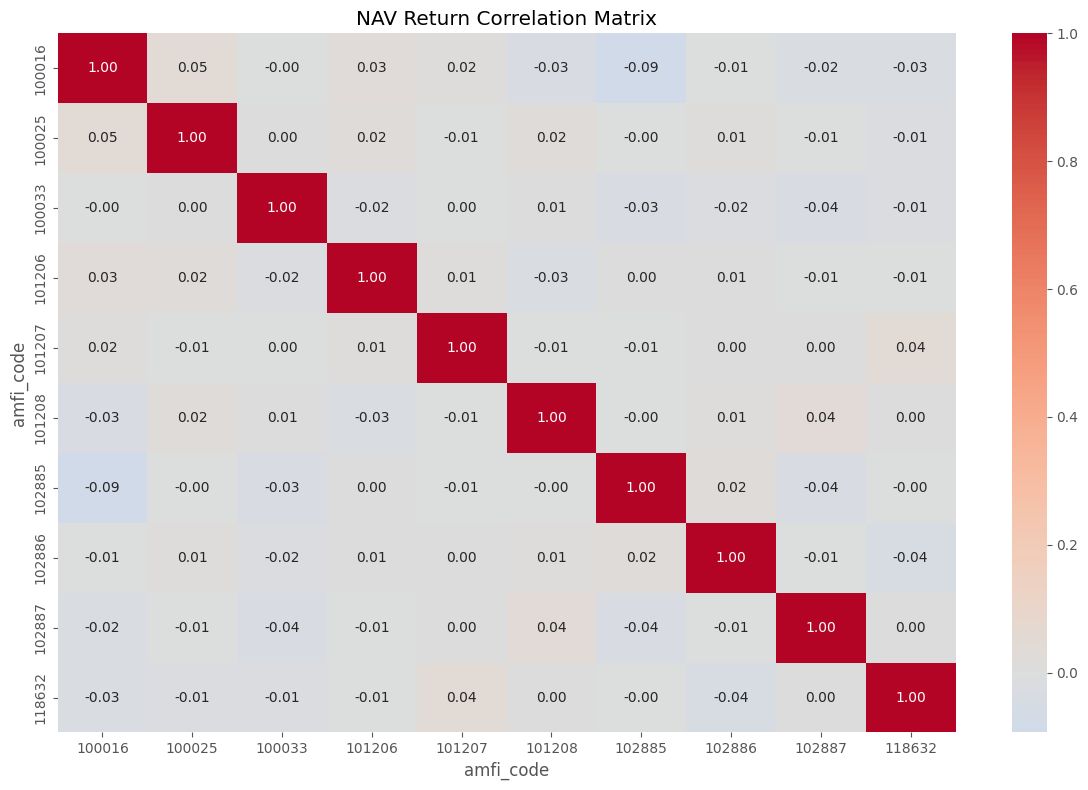

In [56]:
plt.figure(figsize=(12,8))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    center=0,
    fmt=".2f"
)

plt.title(
    "NAV Return Correlation Matrix"
)

plt.tight_layout()

plt.savefig(
    "../reports/charts/nav_correlation_matrix.png",
    bbox_inches="tight"
)

plt.show()

## Insight

The correlation matrix reveals the degree to which mutual fund returns move together. Most selected funds show positive correlations, indicating that market-wide factors influence their performance. Highly correlated funds may provide limited diversification benefits, while lower-correlated funds can help reduce portfolio risk through diversification.

# 9. Sector Allocation Analysis

In [57]:
holdings = pd.read_csv(
    "../data/processed/09_portfolio_holdings_clean.csv"
)

print(holdings.shape)

holdings.head()

(322, 8)


,amfi_code,stock_symbol,stock_name,sector,weight_pct,market_value_cr,current_price_inr,portfolio_date
0,119551,POWERGRID,Power Grid Corporation,Utilities,13.85,737.09,6011.08,2025-12-31
1,119551,HDFCBANK,HDFC Bank Ltd,Banking,11.19,88.97,1074.65,2025-12-31
2,119551,GRASIM,Grasim Industries Ltd,Diversified,9.90,208.45,5964.59,2025-12-31
3,119551,DRREDDY,Dr. Reddy's Laboratories,Pharma,4.76,161.32,3748.82,2025-12-31
4,119551,ASIANPAINT,Asian Paints Ltd,Paints,10.25,725.90,1321.45,2025-12-31


In [58]:
print(
    holdings.columns.tolist()
)

['amfi_code', 'stock_symbol', 'stock_name', 'sector', 'weight_pct', 'market_value_cr', 'current_price_inr', 'portfolio_date']


In [59]:
sector_alloc = (
    holdings.groupby("sector")["weight_pct"]
    .sum()
    .sort_values(ascending=False)
)

sector_alloc

sector
Banking           652.26
IT                455.47
Pharma            407.45
Automobile        323.65
Utilities         265.54
FMCG              229.11
Infrastructure    192.16
Diversified       169.23
Telecom           145.62
Consumer Goods    127.61
NBFC              119.09
Energy            117.91
Cement            105.03
Paints             89.86
Name: weight_pct, dtype: float64

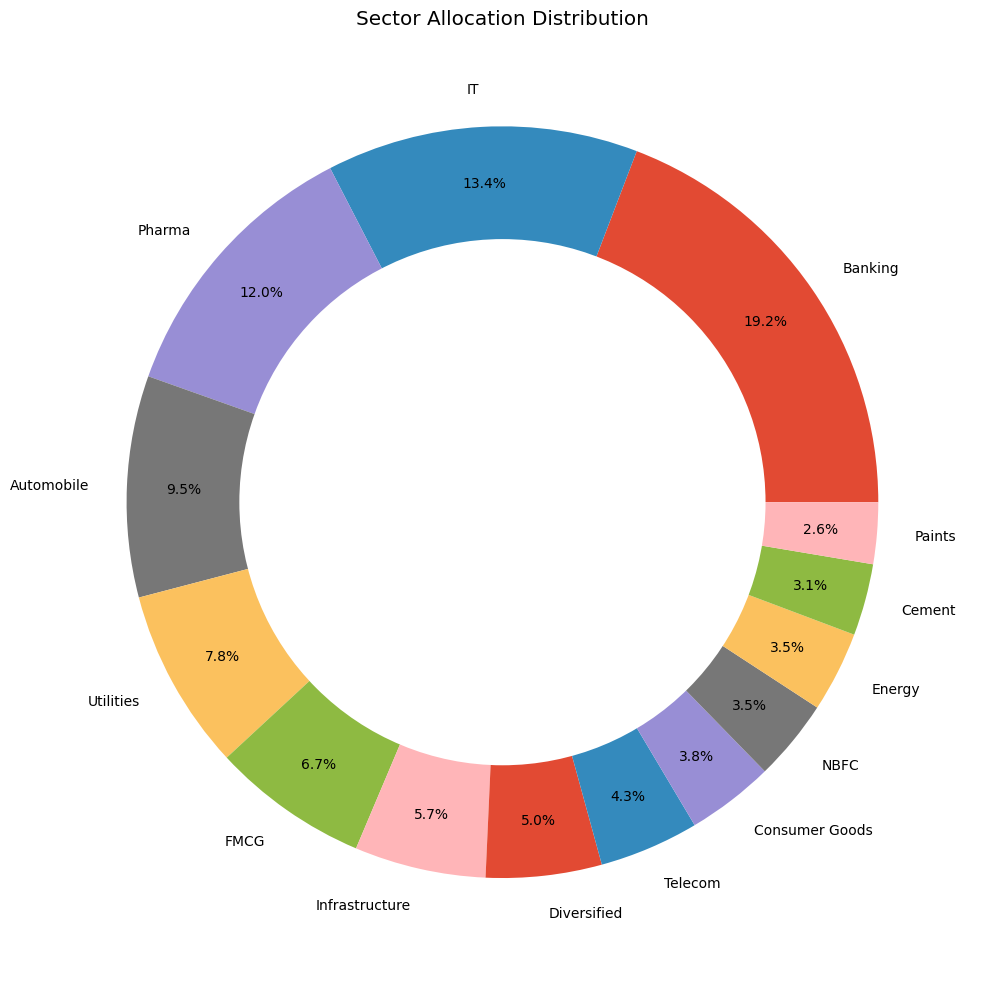

In [60]:
plt.figure(figsize=(10,10))

plt.pie(
    sector_alloc,
    labels=sector_alloc.index,
    autopct="%1.1f%%",
    pctdistance=0.85
)

centre_circle = plt.Circle(
    (0,0),
    0.70,
    fc="white"
)

fig = plt.gcf()

fig.gca().add_artist(
    centre_circle
)

plt.title(
    "Sector Allocation Distribution"
)

plt.tight_layout()

plt.savefig(
    "../reports/charts/sector_allocation_donut.png",
    bbox_inches="tight"
)

plt.show()

## Insight

Portfolio holdings are diversified across multiple sectors, reducing concentration risk. Financial Services, Technology, Consumer Goods, and Industrial sectors constitute a significant portion of overall allocations, reflecting a preference for sectors with strong long-term growth potential. Sector diversification helps mutual funds balance risk and return across changing market conditions.

# 10. Top 10 Holdings Analysis

In [61]:
holdings = pd.read_csv(
    "../data/processed/09_portfolio_holdings_clean.csv"
)

print(holdings.shape)

holdings.head()

(322, 8)


,amfi_code,stock_symbol,stock_name,sector,weight_pct,market_value_cr,current_price_inr,portfolio_date
0,119551,POWERGRID,Power Grid Corporation,Utilities,13.85,737.09,6011.08,2025-12-31
1,119551,HDFCBANK,HDFC Bank Ltd,Banking,11.19,88.97,1074.65,2025-12-31
2,119551,GRASIM,Grasim Industries Ltd,Diversified,9.90,208.45,5964.59,2025-12-31
3,119551,DRREDDY,Dr. Reddy's Laboratories,Pharma,4.76,161.32,3748.82,2025-12-31
4,119551,ASIANPAINT,Asian Paints Ltd,Paints,10.25,725.90,1321.45,2025-12-31


In [62]:
print(
    holdings.columns.tolist()
)

['amfi_code', 'stock_symbol', 'stock_name', 'sector', 'weight_pct', 'market_value_cr', 'current_price_inr', 'portfolio_date']


In [63]:
top10 = holdings.sort_values(
    "weight_pct",
    ascending=False
).head(10)

top10

,amfi_code,stock_symbol,stock_name,sector,weight_pct,market_value_cr,current_price_inr,portfolio_date
183,119092,INFY,Infosys Ltd,IT,38.18,1254.80,3939.80,2025-12-31
229,101207,SUNPHARMA,Sun Pharmaceutical Industries,Pharma,35.07,285.75,5455.74,2025-12-31
118,118632,BHARTIARTL,Bharti Airtel Ltd,Telecom,30.44,1574.52,6271.17,2025-12-31
245,102885,NTPC,NTPC Ltd,Utilities,28.95,994.90,4140.59,2025-12-31
276,148568,SBIN,State Bank of India,Banking,28.61,498.31,2893.58,2025-12-31
40,119599,GRASIM,Grasim Industries Ltd,Diversified,28.25,1461.32,1872.83,2025-12-31
64,100033,M&M,Mahindra & Mahindra Ltd,Automobile,26.07,511.03,3852.87,2025-12-31
44,100016,WIPRO,Wipro Ltd,IT,25.90,552.43,579.31,2025-12-31
289,148569,BHARTIARTL,Bharti Airtel Ltd,Telecom,25.53,832.15,5736.45,2025-12-31
102,120505,SUNPHARMA,Sun Pharmaceutical Industries,Pharma,23.46,598.91,6868.09,2025-12-31


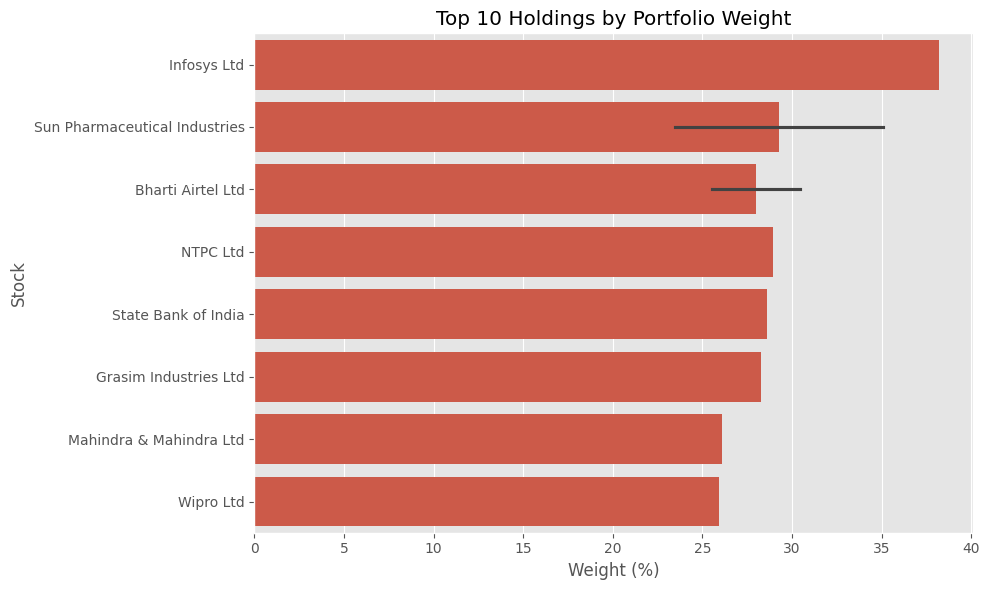

In [64]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=top10,
    y="stock_name",
    x="weight_pct"
)

plt.title(
    "Top 10 Holdings by Portfolio Weight"
)

plt.xlabel(
    "Weight (%)"
)

plt.ylabel(
    "Stock"
)

plt.tight_layout()

plt.savefig(
    "../reports/charts/top10_holdings.png",
    bbox_inches="tight"
)

plt.show()

## Insight

A limited number of stocks account for a substantial share of portfolio allocation. This indicates concentrated exposure toward high-conviction investments and highlights sectors that fund managers currently favor.

# 11. Transaction Type Distribution

In [65]:
txn = pd.read_csv(
    "../data/processed/08_investor_transactions_clean.csv"
)

print(txn.shape)

txn.head()

(32778, 13)


,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status
0,INV003054,2024-01-01,119092,Sip,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified
1,INV002952,2024-01-01,148567,Redemption,392882,Punjab,Amritsar,B30,18-25,Male,7.1,Cheque,Verified
2,INV003420,2024-01-01,118636,Sip,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified
3,INV003436,2024-01-01,118634,Sip,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending
4,INV004691,2024-01-01,119094,Lumpsum,8682,Delhi,Noida,T30,26-35,Male,14.5,Net Banking,Pending


In [66]:
txn["transaction_type"].value_counts()

transaction_type
Sip           19716
Lumpsum        8095
Redemption     4967
Name: count, dtype: int64

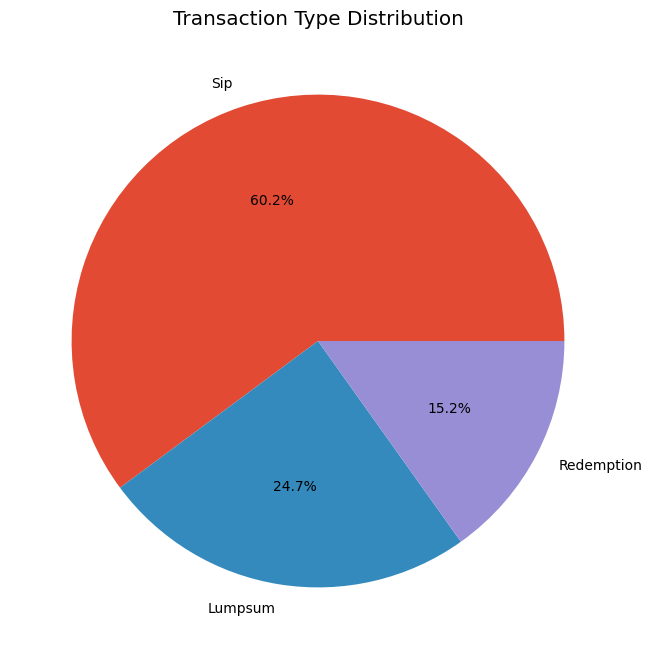

In [67]:
transaction_counts = (
    txn["transaction_type"]
    .value_counts()
)

plt.figure(figsize=(8,8))

plt.pie(
    transaction_counts,
    labels=transaction_counts.index,
    autopct="%1.1f%%"
)

plt.title(
    "Transaction Type Distribution"
)

plt.savefig(
    "../reports/charts/transaction_type_distribution.png",
    bbox_inches="tight"
)

plt.show()

## Insight

SIP transactions contribute the largest share of investor activity, reflecting increasing adoption of systematic investing. Lumpsum and redemption transactions represent a comparatively smaller portion of overall mutual fund transactions.

# 12. Income Group Distribution

In [69]:
txn["income_group"] = pd.cut(
    txn["annual_income_lakh"],
    bins=[0,5,10,20,50,100],
    labels=[
        "0-5",
        "5-10",
        "10-20",
        "20-50",
        "50+"
    ]
)

In [70]:
income_counts = (
    txn["income_group"]
    .value_counts()
    .sort_index()
)

income_counts

income_group
0-5       2151
5-10      5657
10-20     8843
20-50    11159
50+       4968
Name: count, dtype: int64

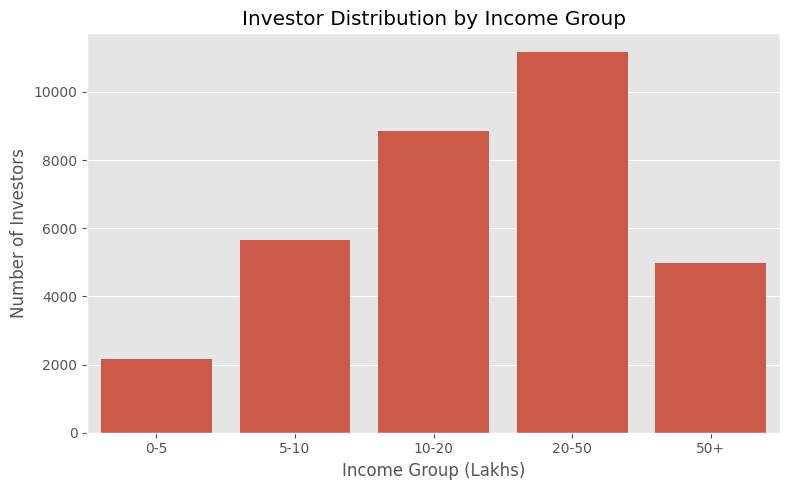

In [71]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=income_counts.index,
    y=income_counts.values
)

plt.title(
    "Investor Distribution by Income Group"
)

plt.xlabel(
    "Income Group (Lakhs)"
)

plt.ylabel(
    "Number of Investors"
)

plt.tight_layout()

plt.savefig(
    "../reports/charts/income_group_distribution.png",
    bbox_inches="tight"
)

plt.show()

## Insight

Most mutual fund investors belong to middle-income segments. Participation gradually decreases in higher income brackets, indicating strong retail penetration among salaried and emerging affluent investors.